# Lab 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

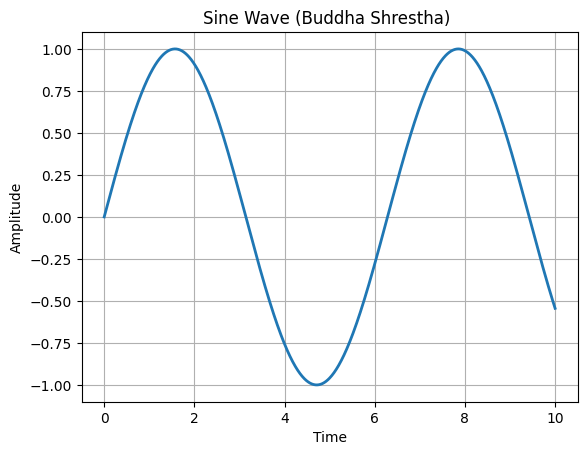

In [25]:
# --- 1. Sine Wave ---
n1 = np.arange(0, 10.01, 0.01)
y1 = np.sin(n1)
plt.plot(n1, y1, linewidth=2)
plt.title('Sine Wave (Buddha Shrestha) ')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(True)
# plt.savefig('Sin.png')

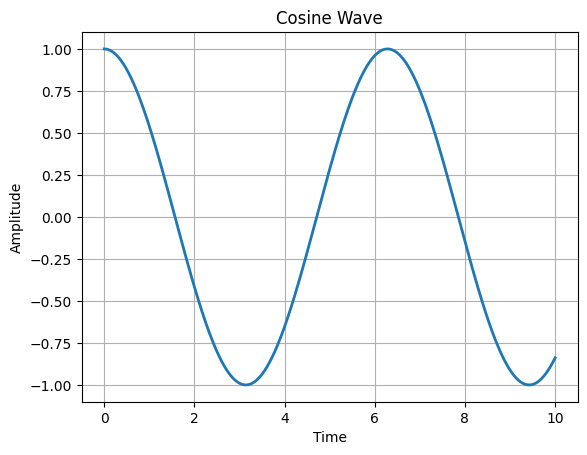

In [26]:
# --- 2. Cosine Wave ---
y2 = np.cos(n1)
plt.plot(n1, y2, linewidth=2)
plt.title('Cosine Wave')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(True)
# plt.savefig('Cosine.png')

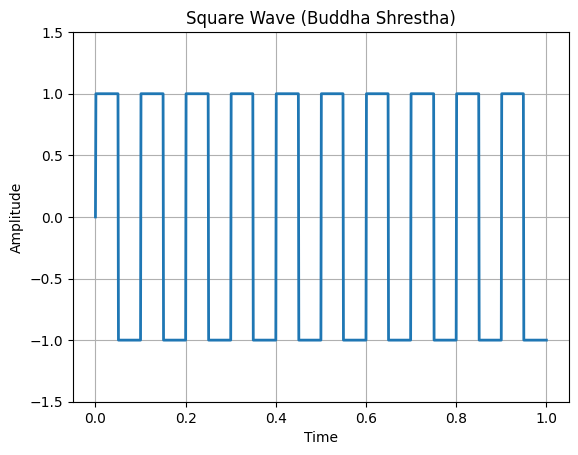

In [27]:
# --- 3. Square Wave ---
Fs = 1000
t1 = np.arange(0, 1 + 1/Fs, 1/Fs)
f = 10
y3 = np.sign(np.sin(2 * np.pi * f * t1))
plt.plot(t1, y3, linewidth=2)
plt.ylim([-1.5, 1.5])
plt.title('Square Wave (Buddha Shrestha)')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(True)
# plt.savefig('Square.png')

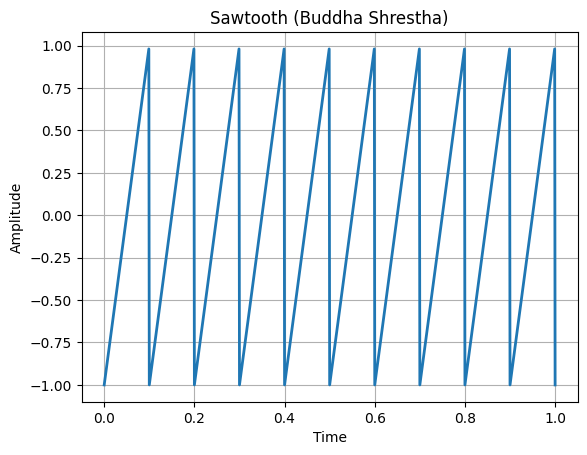

In [28]:
# --- 4. Sawtooth Wave ---
y4 = signal.sawtooth(2 * np.pi * f * t1)
plt.plot(t1, y4, linewidth=2)
plt.title('Sawtooth (Buddha Shrestha)')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(True)
# plt.savefig('Sawtooth.png')

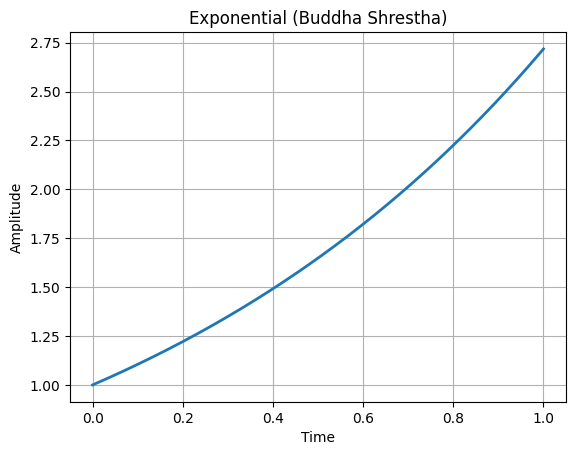

In [29]:
# --- 5. Exponential Wave ---
expo = np.exp(t1)
plt.plot(t1, expo, linewidth=2)
plt.title('Exponential (Buddha Shrestha)')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(True)
# plt.savefig('Exponential.png')

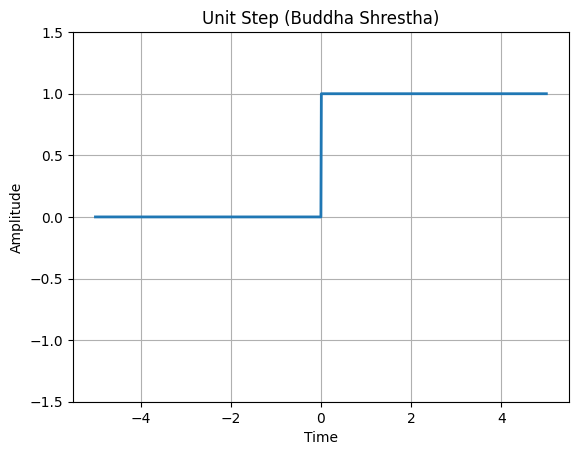

In [30]:
# Time vector for standard continuous-time signals
t2 = np.arange(-5, 5.01, 0.01)

# --- 6. Unit Step ---
y6 = (t2 >= 0).astype(float)
plt.plot(t2, y6, linewidth=2)
plt.ylim([-1.5, 1.5])
plt.title('Unit Step (Buddha Shrestha)')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(True)
# plt.savefig('UnitStep.png')

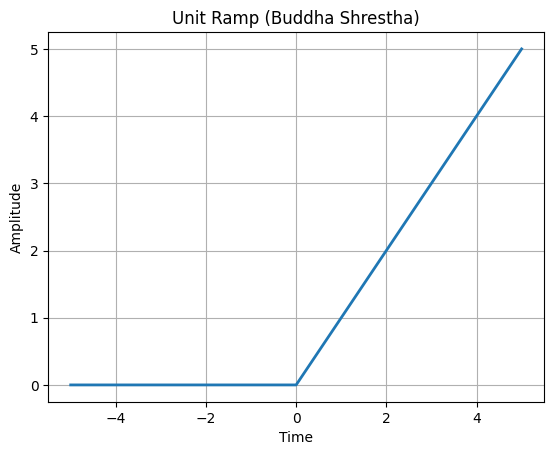

In [31]:
# --- 7. Unit Ramp ---
y7 = t2 * (t2 > 0)
plt.plot(t2, y7, linewidth=2)
plt.title('Unit Ramp (Buddha Shrestha)')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(True)
# plt.savefig('UnitRamp.png')

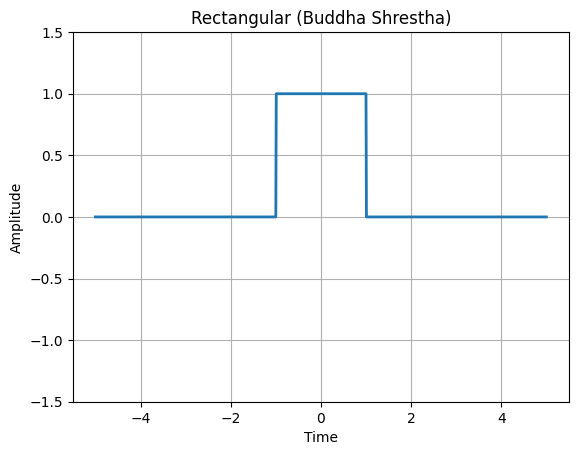

In [32]:
# --- 8. Rectangular Pulse ---
y8 = (np.abs(t2) <= 1).astype(float)
plt.plot(t2, y8, linewidth=2)
plt.ylim([-1.5, 1.5])
plt.title('Rectangular (Buddha Shrestha)')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(True)
# plt.savefig('Rectangular.png')

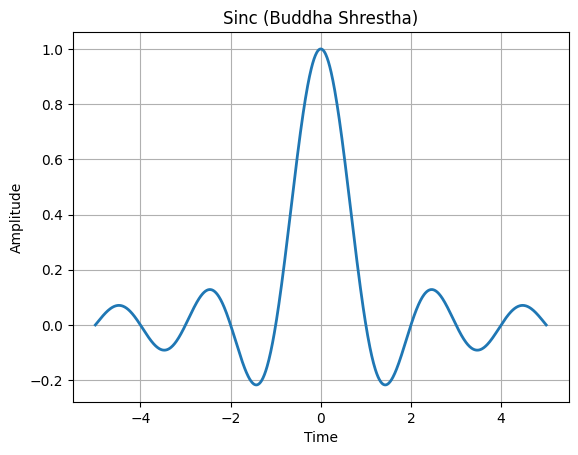

In [33]:
# --- 9. Sinc Function ---
# Note: np.sinc(x) computes sin(pi*x) / (pi*x) in NumPy
y9 = np.sinc(t2) 
plt.plot(t2, y9, linewidth=2)
plt.title('Sinc (Buddha Shrestha)')
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.grid(True)
# plt.savefig('Sinc.png')

# Lab 2 Sampling and Recontruction

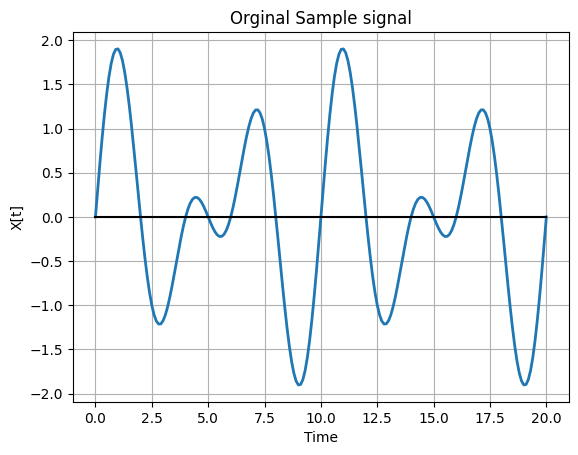

In [34]:
t = np.arange(0,20.1,0.1)
f1 = 0.2
f2 = 0.3
x = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)
plt.plot(t,x, linewidth = 2)
plt.plot([0,20], [0, 0], color = 'black')
plt.title('Orginal Sample signal')
plt.xlabel("Time")
plt.ylabel("X[t]")
plt.grid(True)
# plt.savefig('SampleContinuous.png')

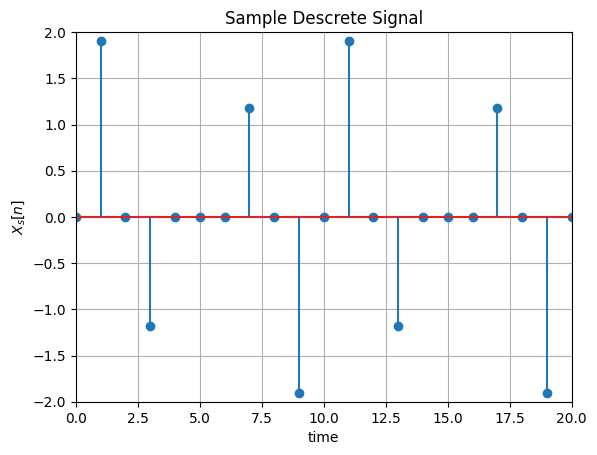

In [35]:
x_sample = x[::10]
n_sample = np.arange(len(x_sample))
plt.stem(n_sample, x_sample, markerfmt='o')
plt.title("Sample Descrete Signal")
plt.xlabel("time")
plt.ylabel("$X_s[n]$")
plt.xlim(0,20)
plt.ylim(-2,2)
plt.grid(True)
# plt.savefig('SampledDiscrete.png')

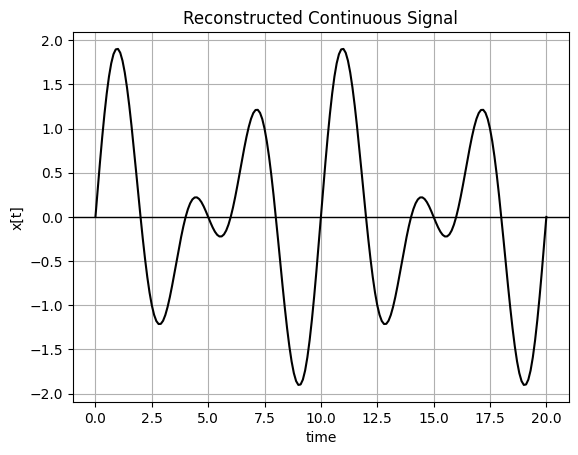

In [36]:
d = len(x_sample)


for k in range(d):
    plt.clf()  # Clear figure to update the animation frame
    
    # Bottom subplot: Reference Original Signal
    plt.plot(t, x, color='black', label='Original')
    # plt.stem(n_sample[:k+1], x_sample[:k+1], markerfmt='o', linefmt='C0-', basefmt=' ')
    plt.axhline(0, color='black', linewidth=1)
    plt.title('Reconstructed Continuous Signal')
    plt.xlabel('time')
    plt.ylabel('x[t]')
    plt.grid(True)

# plt.savefig('ReconstructionContinuous.png')


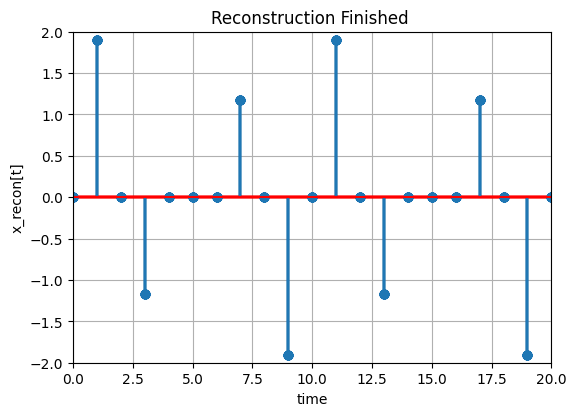

In [37]:
x_recon = np.zeros_like(t)
Ts = 1
for k in range(d):
    # Top subplot: Reconstruction progress
    plt.stem(n_sample * Ts, x_sample, basefmt=" ", markerfmt="o", label='Samples')
    plt.plot([0,20], [0,0], color='red', label='Original')
    
    # Calculate the sinc contribution of the k-th sample across all continuous time 't1'
    # Note: np.sinc in numpy is normalized: sinc(x) = sin(pi*x) / (pi*x)
    sinc_contribution = x_sample[k] * np.sinc((t - k * Ts) / Ts)
    x_recon += sinc_contribution
    
    # Plot individual sinc component and the running total accumulation
    # plt.plot(t, sinc_contribution, 'r--', alpha=0.6, label=f'Sinc component {k}')
    # plt.plot(t, x_recon, 'g', label='Accumulated Reconstruction')
    
    if k == d - 1:
        plt.title('Reconstruction Finished ')
    else:
        plt.title(f'Sample-by-Sample Reconstruction (Step {k+1}/{d}) ')
        
    plt.xlim(0, 20)
    plt.ylim(-2, 2)
    plt.xlabel('time')
    plt.ylabel('x_recon[t]')
    plt.grid(True)
    
    plt.tight_layout(pad=3.0,w_pad=2.0, h_pad=4.0)

# plt.savefig('ReconstructionDiscrete.png')

# Lab 3 TDM

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

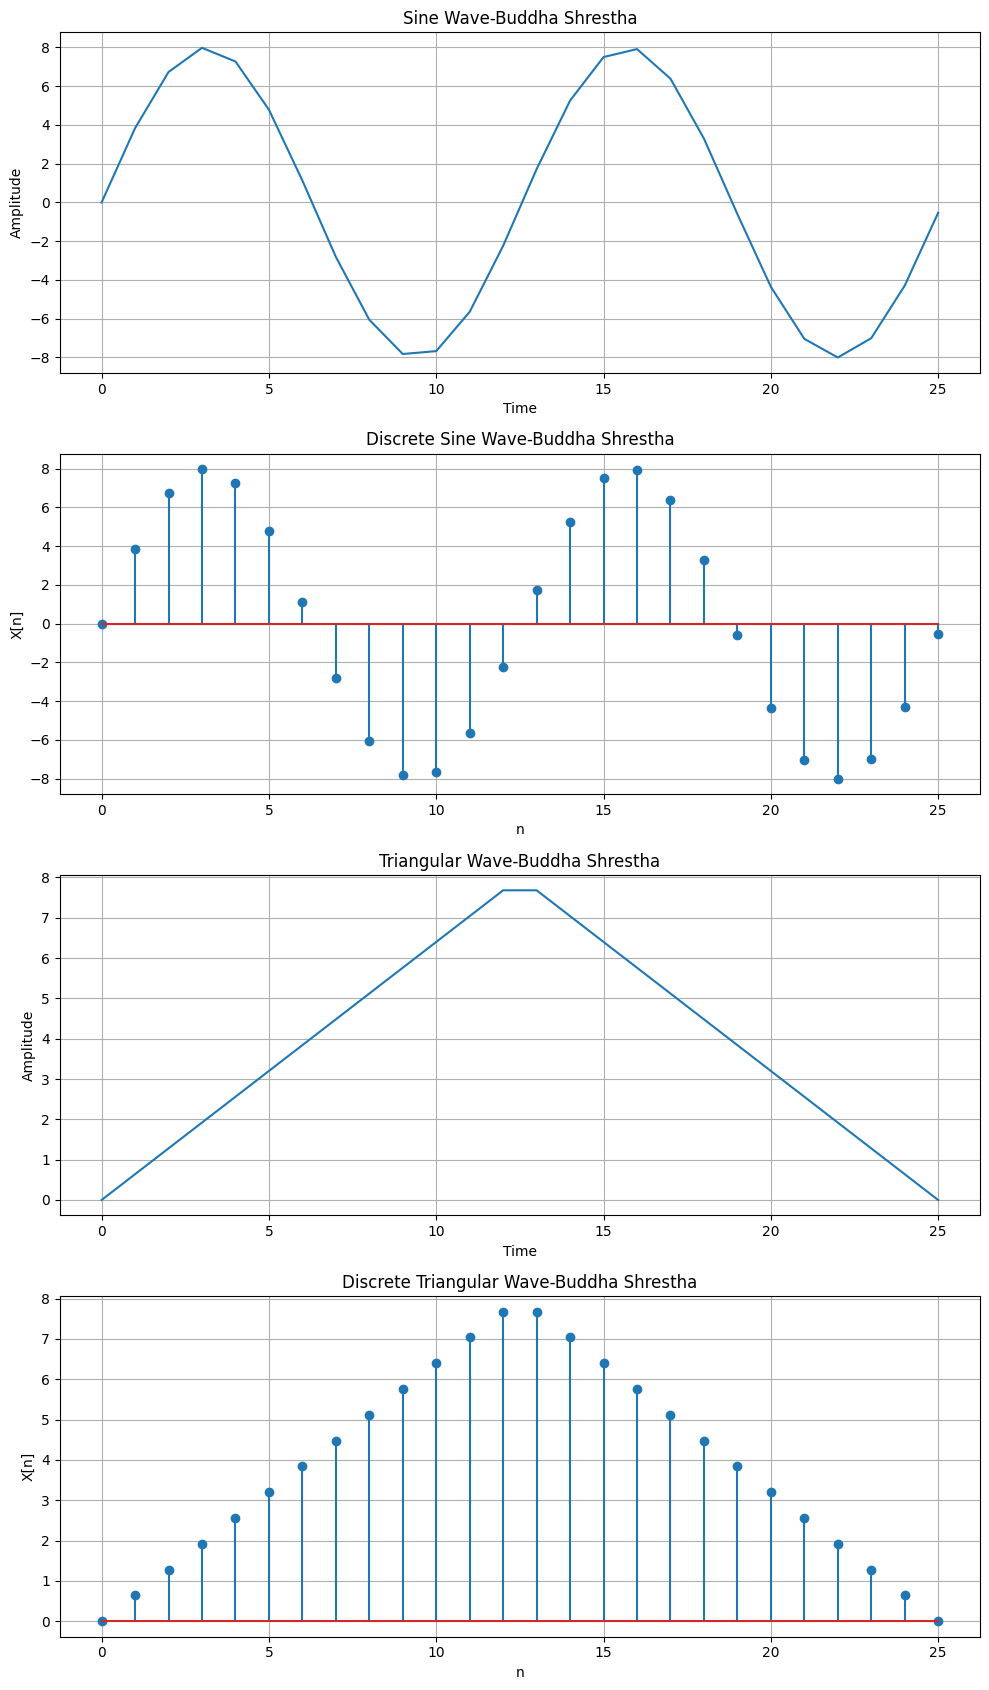

In [39]:
# range x
x = np.arange(0,4*np.pi, 0.5)

# Amplitude
A = 8

# Signal
signal1 = A * np.sin(x)

# length
l = len(signal1)

# Signal 2
signal2 = A * (1 - np.abs(np.linspace(-1,1,l)))
fig,(ax1,ax2,ax3,ax4) = plt.subplots(4,1,figsize=(10,17))
ax1.plot(signal1)
ax1.set_title('Sine Wave-Buddha Shrestha')
ax1.set_xlabel('Time')
ax1.set_ylabel('Amplitude')
ax1.grid()

ax2.stem(signal1)
ax2.set_title('Discrete Sine Wave-Buddha Shrestha')
ax2.set_xlabel('n')
ax2.set_ylabel('X[n]')
ax2.grid()

ax3.plot(signal2)
ax3.set_title('Triangular Wave-Buddha Shrestha')
ax3.set_xlabel('Time')
ax3.set_ylabel('Amplitude')
ax3.grid()

ax4.stem(signal2)
ax4.set_title('Discrete Triangular Wave-Buddha Shrestha')
ax4.set_xlabel('n')
ax4.set_ylabel('X[n]')
ax4.grid()
plt.tight_layout()
# plt.savefig('OrginalSignal.png')

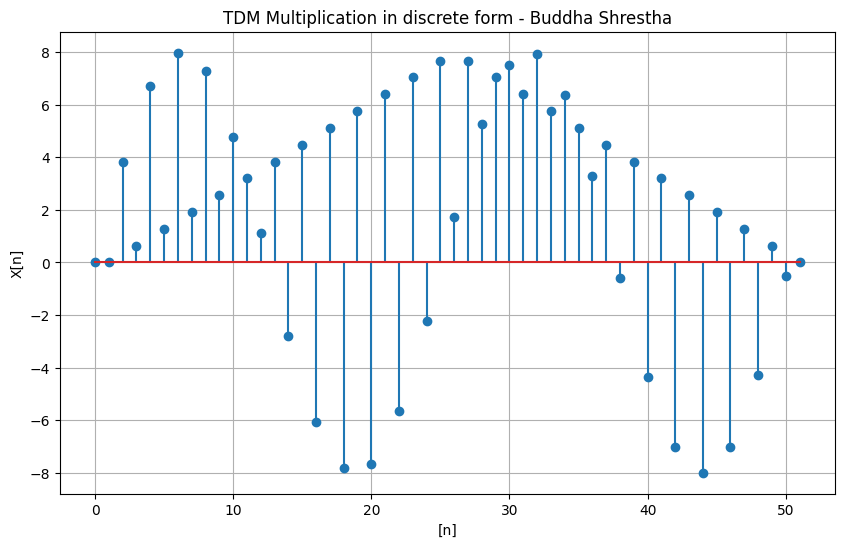

In [40]:
# TDM Multiplication
signal_matrix = np.vstack((signal1, signal2))
tdm_signal = signal_matrix.flatten(order='F')

plt.figure(figsize=(10, 6))
plt.stem(tdm_signal)
plt.title('TDM Multiplication in discrete form - Buddha Shrestha')
plt.xlabel('[n]')
plt.ylabel('X[n]')
plt.grid(True)
# plt.savefig('TDM.png')

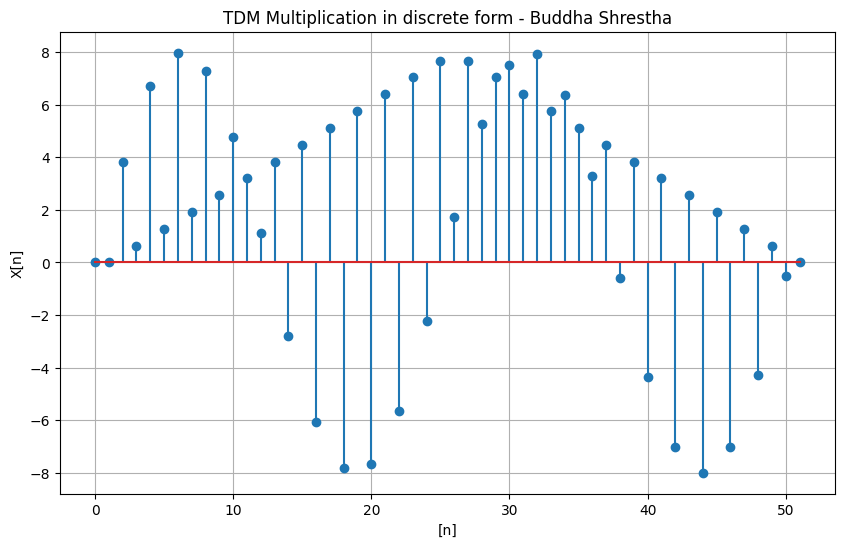

In [41]:
l1 = len(signal1)
l2 = len(signal2)

# create a numeric array (avoid name 'signal' which is a module)
sig = np.zeros((2, max(l1, l2)), dtype=float)

# copy available samples (handles unequal lengths safely)
sig[0, :l1] = signal1
sig[1, :l2] = signal2

tdm_signal = sig.flatten(order='F')
plt.figure(figsize=(10, 6))
plt.stem(tdm_signal.flatten(order='F'))
plt.title('TDM Multiplication in discrete form - Buddha Shrestha')
plt.xlabel('[n]')
plt.ylabel('X[n]')
plt.grid(True)  
# plt.save_fig('TDM.png')


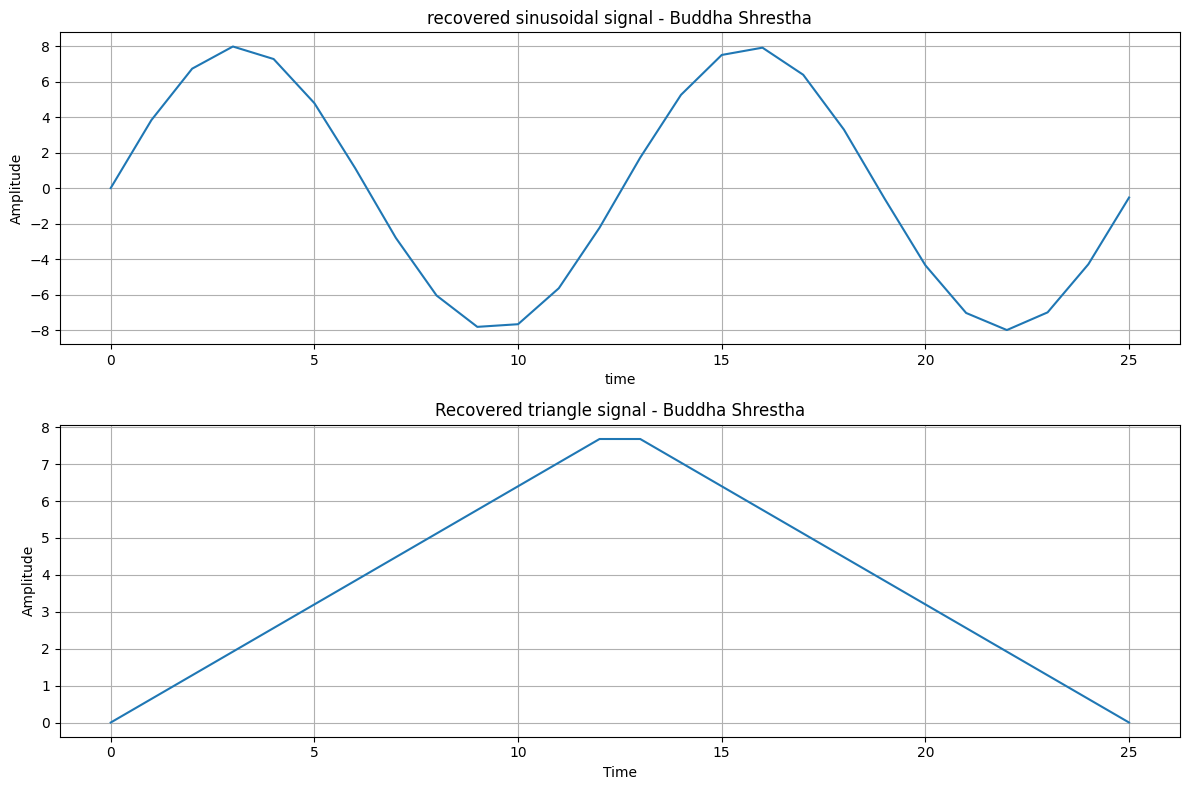

In [42]:
demux = tdm_signal.reshape(2, l, order='F')
signal3 = demux[0, :]
signal4 = demux[1, :]

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(signal3)
plt.title('recovered sinusoidal signal - Buddha Shrestha')
plt.xlabel('time')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(signal4)
plt.title('Recovered triangle signal - Buddha Shrestha')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
# plt.savefig('Demux.png')

Mean Squared Error (MSE): 0.1238


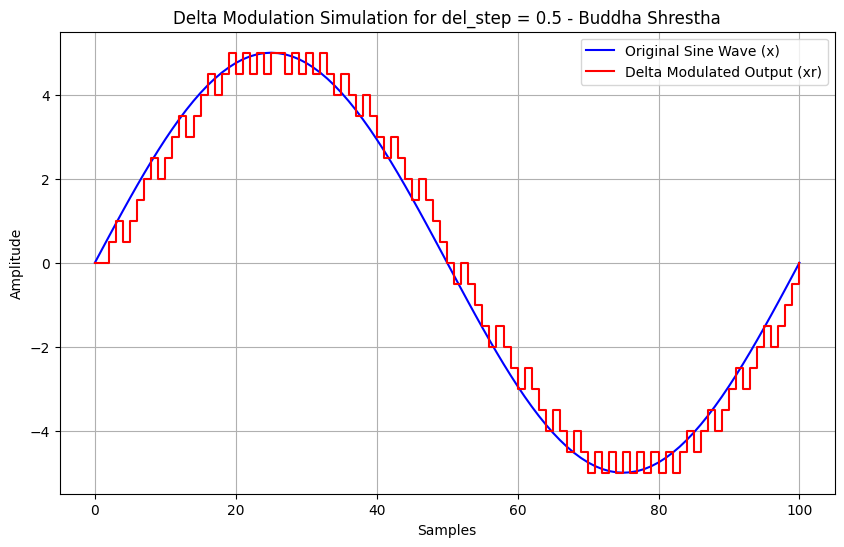

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Clear output equivalent - prompt user for step size input
try:
    del_step = float(input('Enter step size:\n'))
except ValueError:
    print("Invalid input. Using default step size of 0.5.")
    del_step = 0.5

# Time vector: 0 to 2*pi with spacing matching 2*pi/100
t = np.arange(0, 2 * np.pi + (2 * np.pi / 100), 2 * np.pi / 100)
x = 5 * np.sin(t)

# Initialize tracking lists
y = [0]       # Binary data stream output
xr = [0.0]    # Reconstructed signal tracking (starts at 0)

# Delta Modulation Processing Loop
for i in range(len(x) - 1):
    if xr[i] < x[i]:
        d = 1
        xr.append(xr[i] + del_step)
    elif xr[i] == x[i]:
        d = 1
        xr.append(xr[i])
    else:
        d = 0
        xr.append(xr[i] - del_step)
    
    y.append(d)

# Convert lists to NumPy arrays for calculation and plotting
xr = np.array(xr)
y = np.array(y)

# Calculate Mean Squared Error (MSE)
mse = np.sum((x - xr) ** 2) / len(x)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Plotting the Results
plt.figure(figsize=(10, 6))

# Plot continuous reference signal
plt.plot(x, label='Original Sine Wave (x)', color='blue')

# Plot discrete step approximation using step function
plt.step(range(len(xr)), xr, where='post', label='Delta Modulated Output (xr)', color='red', linewidth=1.5)

plt.title(f'Delta Modulation Simulation for del_step = {del_step} - Buddha Shrestha')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
# plt.savefig('DeltaModulation.png')

# Lab 4

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, lfilter


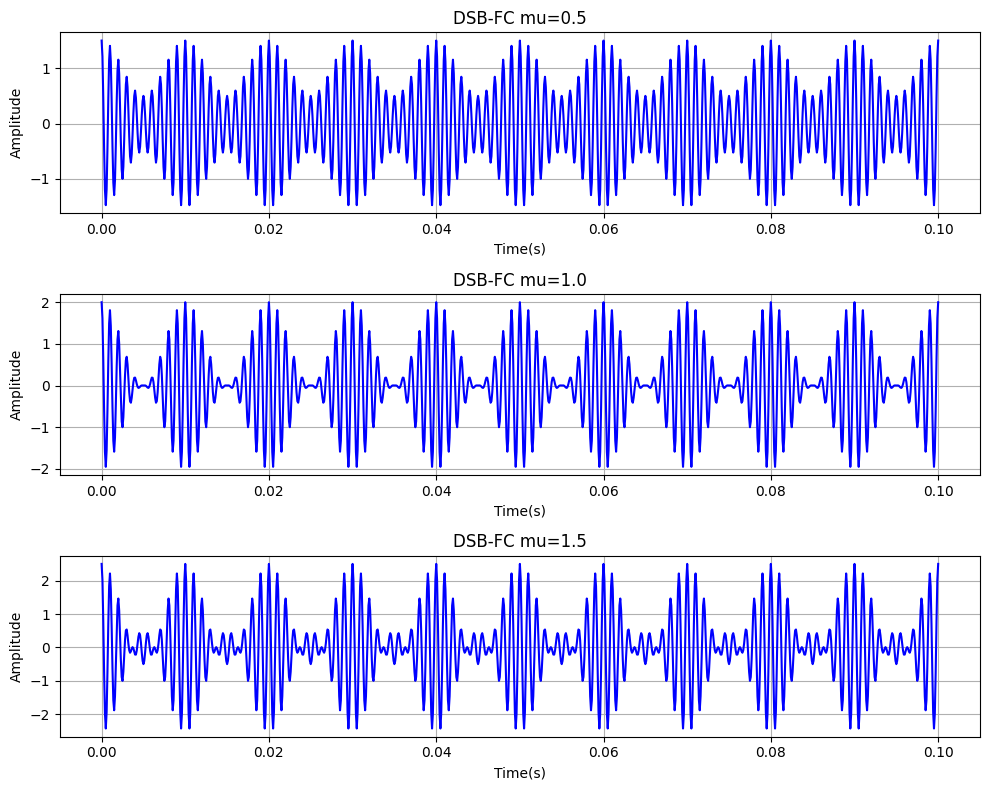

In [45]:
# -------------------------------------------------------------------------
# Initialization & Setup
# -------------------------------------------------------------------------
fs = 10000
t = np.arange(0, 0.1 + 1/fs, 1/fs)  # Equivalent to 0:1/fs:0.1
fc = 1000
fm = 100
Am = 1
Ac = 1
mu = 0.5

m = Am * np.cos(2 * np.pi * fm * t)
c = Ac * np.cos(2 * np.pi * fc * t)
N = len(t)

# Frequency axis calculation
f_axis = np.arange(-N/2, N/2) * (fs / N)

# -------------------------------------------------------------------------
# Part A: DSB-FC with different modulation indices
# -------------------------------------------------------------------------
plt.figure(1, figsize=(10, 8))
mu_vals = [0.5, 1.0, 1.5]

for i, mu_val in enumerate(mu_vals, start=1):
    s = Ac * (1 + mu_val * m / Am) * c
    plt.subplot(3, 1, i)
    plt.plot(t, s, 'b')
    plt.title(f'DSB-FC mu={mu_val:.1f}')
    plt.xlabel('Time(s)')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.savefig('DSB-FC.png')

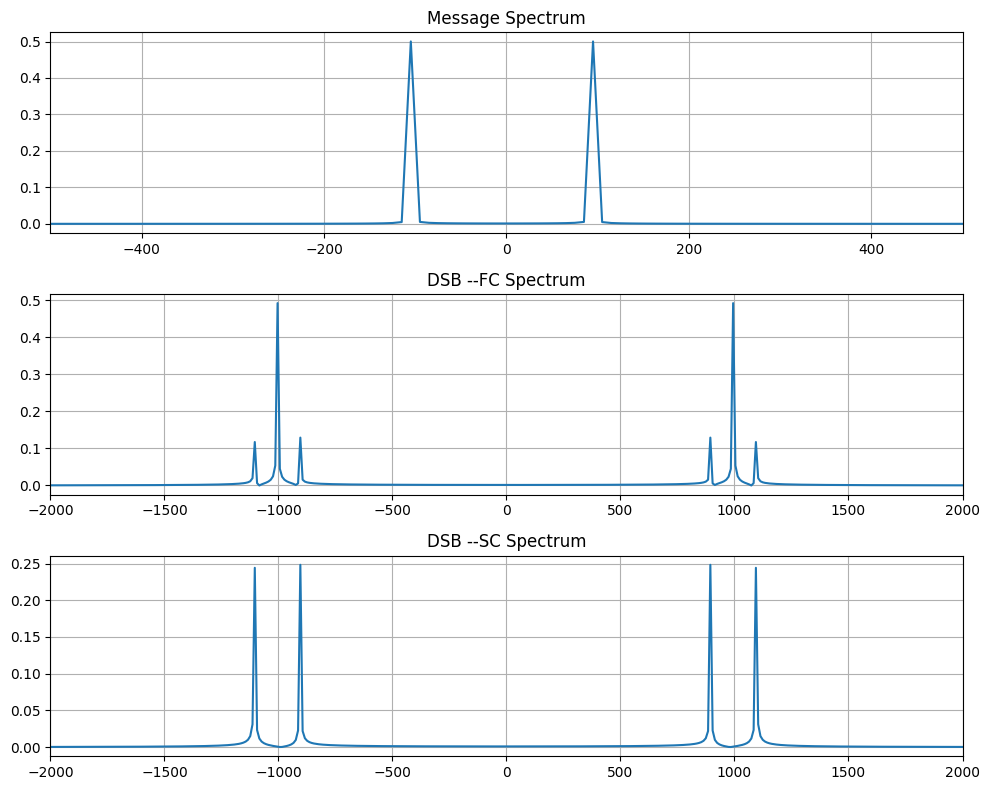

In [46]:
# -------------------------------------------------------------------------
# Part B: Spectrum Analysis (Message, DSB-FC, DSB-SC)
# -------------------------------------------------------------------------
am_fc = Ac * (1 + mu * m / Am) * c
am_sc = m * c

plt.figure(2, figsize=(10, 8))

# Message Spectrum
plt.subplot(3, 1, 1)
plt.plot(f_axis, np.abs(np.fft.fftshift(np.fft.fft(m) / N)))
plt.title('Message Spectrum')
plt.xlim([-500, 500])
plt.grid(True)

# DSB-FC Spectrum
plt.subplot(3, 1, 2)
plt.plot(f_axis, np.abs(np.fft.fftshift(np.fft.fft(am_fc) / N)))
plt.title('DSB --FC Spectrum')
plt.xlim([-2000, 2000])
plt.grid(True)

# DSB-SC Spectrum
plt.subplot(3, 1, 3)
plt.plot(f_axis, np.abs(np.fft.fftshift(np.fft.fft(am_sc) / N)))
plt.title('DSB --SC Spectrum')
plt.xlim([-2000, 2000])
plt.grid(True)

plt.tight_layout()
plt.savefig('DSB-FC-Spectrum.png')

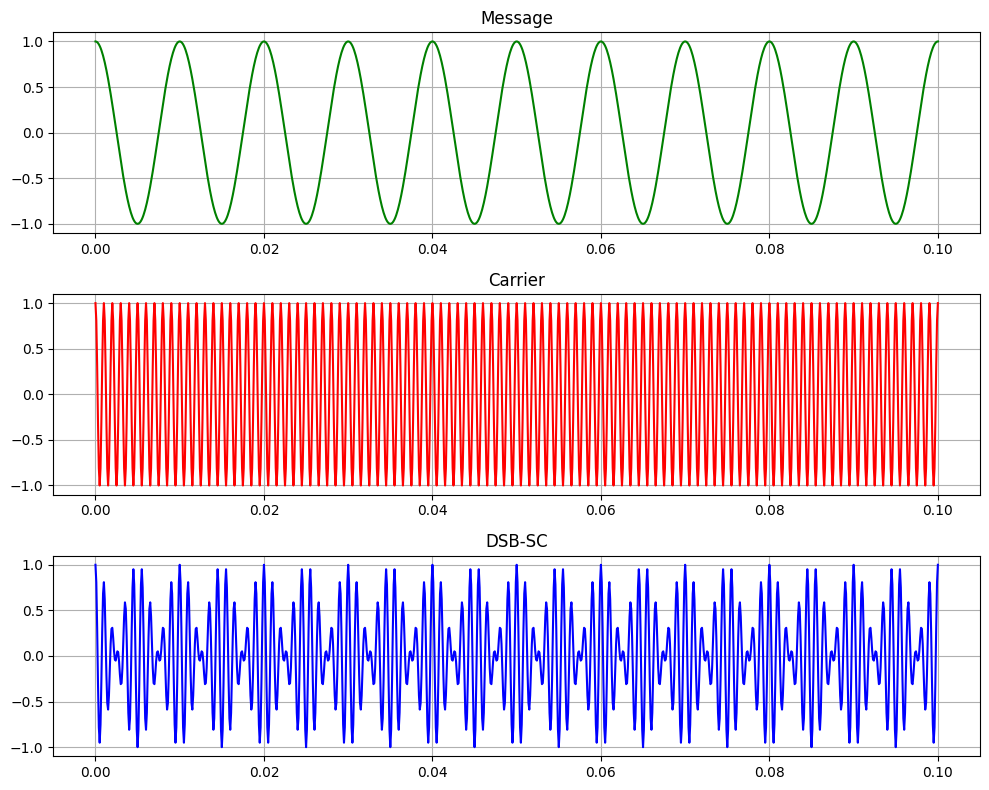

In [59]:

# -------------------------------------------------------------------------
# Part C: Time Domain Signals (Message, Carrier, DSB-SC)
# -------------------------------------------------------------------------
plt.figure(3, figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t, m, 'g')
plt.title('Message')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, c, 'r')
plt.title('Carrier')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, am_sc, 'b')
plt.title('DSB-SC')
plt.grid(True)

plt.tight_layout()
plt.savefig('TimeDomainSignals.png')

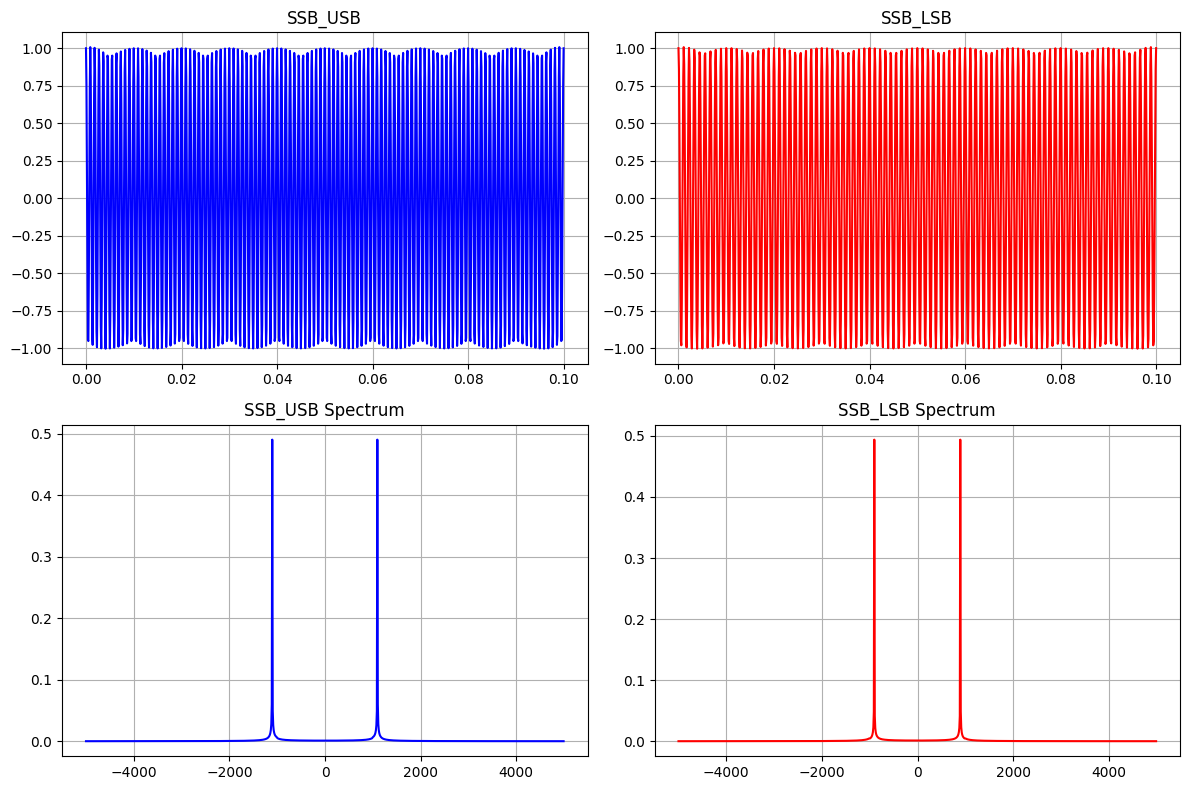

In [48]:

# -------------------------------------------------------------------------
# Part D: Single Sideband (SSB) Generation and Spectrum
# -------------------------------------------------------------------------
# Note: scipy.signal.hilbert returns the analytic signal (real + j*imag).
# To get just the Hilbert transform component (m_hat), we take the imaginary part.
m_hat = np.imag(hilbert(m))

ssb_usb = m * np.cos(2 * np.pi * fc * t) - m_hat * np.sin(2 * np.pi * fc * t)
ssb_lsb = m * np.cos(2 * np.pi * fc * t) + m_hat * np.sin(2 * np.pi * fc * t)

plt.figure(4, figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(t, ssb_usb, 'b')
plt.title('SSB_USB')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(t, ssb_lsb, 'r')
plt.title('SSB_LSB')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(f_axis, np.abs(np.fft.fftshift(np.fft.fft(ssb_usb) / N)), 'b')
plt.title('SSB_USB Spectrum')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(f_axis, np.abs(np.fft.fftshift(np.fft.fft(ssb_lsb) / N)), 'r')
plt.title('SSB_LSB Spectrum')
plt.grid(True)

plt.tight_layout()
plt.savefig('SSB.png')

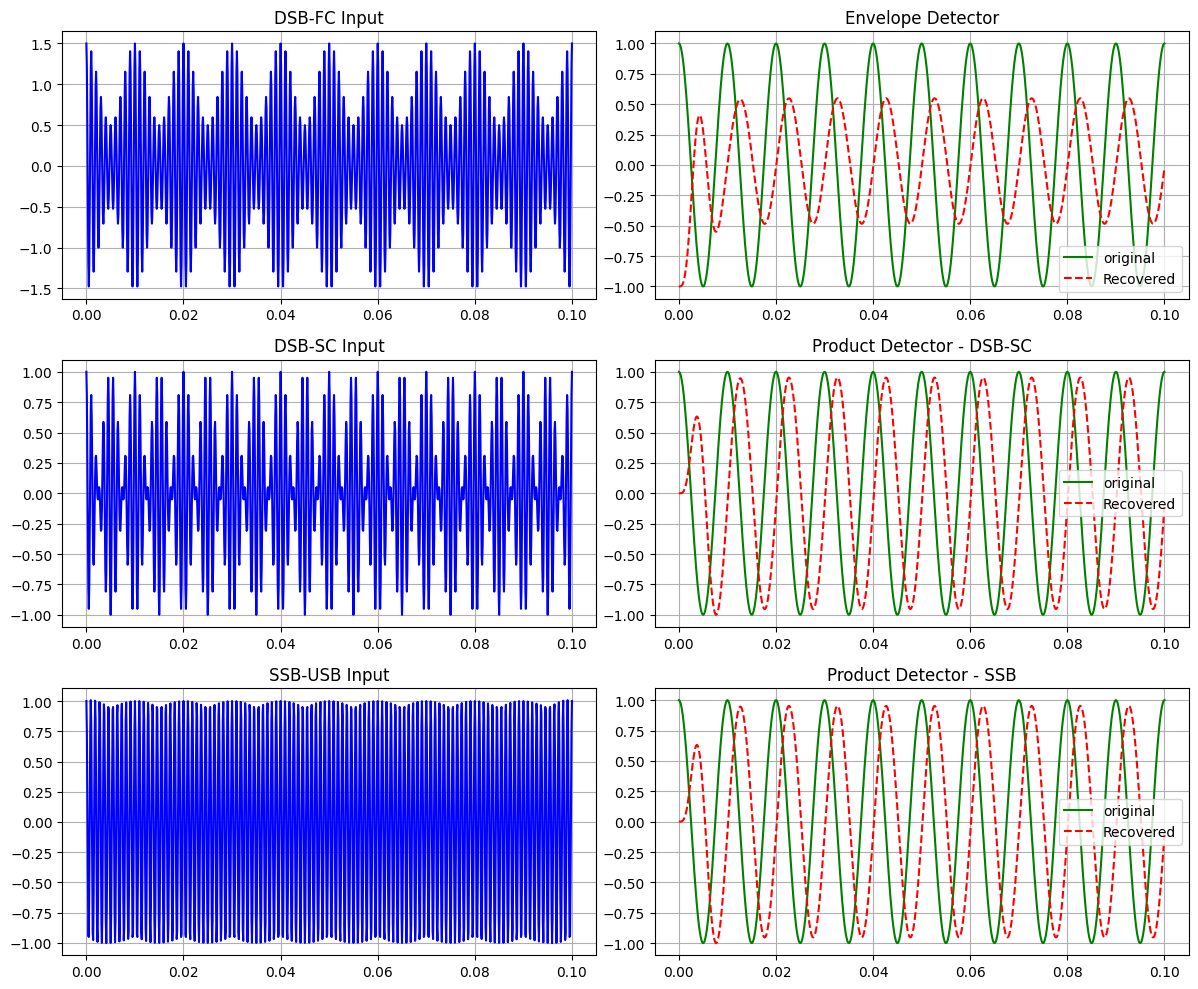

In [49]:
# -------------------------------------------------------------------------
# Part E: Demodulation (Envelope & Product Detection)
# -------------------------------------------------------------------------
# In Python, the normalized digital cutoff frequency Wn is between 0 and 1 (where 1 is Nyquist).
# Your MATLAB code: 2*fm/fs * 2. In Python: (2 * fm) / (fs / 2)
b, a = butter(5, (2 * fm) / (fs / 2))

# 1. Envelope Detector (DSB-FC)
env_det = lfilter(b, a, np.maximum(am_fc, 0))
env_det = env_det - np.mean(env_det)
env_det = env_det / np.max(np.abs(env_det)) * Am

# 2. Product Detector (DSB-SC)
prod_sc = lfilter(b, a, am_sc * c)
prod_sc = prod_sc / np.max(np.abs(prod_sc)) * Am

# 3. Product Detector (SSB)
prod_ssb = lfilter(b, a, ssb_usb * c)
prod_ssb = prod_ssb / np.max(np.abs(prod_ssb)) * Am

plt.figure(5, figsize=(12, 10))

# DSB-FC Plots
plt.subplot(3, 2, 1)
plt.plot(t, am_fc, 'b')
plt.title('DSB-FC Input')
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(t, m, 'g', label='original')
plt.plot(t, env_det, 'r--', label='Recovered')
plt.title('Envelope Detector')
plt.legend()
plt.grid(True)

# DSB-SC Plots
plt.subplot(3, 2, 3)
plt.plot(t, am_sc, 'b')
plt.title('DSB-SC Input')
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(t, m, 'g', label='original')
plt.plot(t, prod_sc, 'r--', label='Recovered')
plt.title('Product Detector - DSB-SC')
plt.legend()
plt.grid(True)

# SSB-USB Plots
plt.subplot(3, 2, 5)
plt.plot(t, ssb_usb, 'b')
plt.title('SSB-USB Input')
plt.grid(True)

plt.subplot(3, 2, 6)
plt.plot(t, m, 'g', label='original')
plt.plot(t, prod_ssb, 'r--', label='Recovered')
plt.title('Product Detector - SSB')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('Demodulation.png')

# Lab 5